In [39]:
from faulthandler import cancel_dump_traceback_later

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from conda.env.env import print_result

from xue import category_stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
df = pd.DataFrame({
    'order_id': range(5001, 5051),
    'category': np.random.choice(['Food', 'Drink', 'Snack', None], 50),
    'price': np.random.rand(50) * 100,
    'quantity': np.random.randint(1, 10, 50).astype(float),
    'discount': np.random.choice([0.1, 0.2, 0.5, None], 50),
    'is_member': np.random.choice(['Yes', 'No'], 50),
    'time': pd.date_range('2026-06-01', periods=50, freq='h')
})
# 故意挖空值
df.loc[0:5, 'price'] = np.nan
df.loc[10:12, 'quantity'] = np.nan
df.loc[20:24, 'discount'] = np.nan
print("超市数据准备完毕！开始手打下方代码。")

超市数据准备完毕！开始手打下方代码。


In [40]:
df.head()

,order_id,category,price,quantity,discount,is_member,time
0,5001,Snack,NaN,3.0,0.1,Yes,2026-06-01 00:00:00
1,5002,NaN,NaN,3.0,0.5,No,2026-06-01 01:00:00
2,5003,Food,NaN,1.0,0.2,Yes,2026-06-01 02:00:00
3,5004,Snack,NaN,5.0,0.1,Yes,2026-06-01 03:00:00
4,5005,Snack,NaN,7.0,None,Yes,2026-06-01 04:00:00


In [41]:
df.shape

(50, 7)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   order_id   50 non-null     int64         
 1   category   34 non-null     str           
 2   price      44 non-null     float64       
 3   quantity   47 non-null     float64       
 4   discount   35 non-null     object        
 5   is_member  50 non-null     str           
 6   time       50 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), object(1), str(2)
memory usage: 2.9+ KB


In [43]:
df.describe()

,order_id,price,quantity,time
count,50.00000,44.000000,47.000000,50
mean,5025.50000,48.766116,5.042553,2026-06-02 00:30:00
min,5001.00000,0.552212,1.000000,2026-06-01 00:00:00
25%,5013.25000,19.320076,3.000000,2026-06-01 12:15:00
50%,5025.50000,46.766470,5.000000,2026-06-02 00:30:00
75%,5037.75000,80.374707,7.000000,2026-06-02 12:45:00
max,5050.00000,98.688694,9.000000,2026-06-03 01:00:00
std,14.57738,32.551235,2.553407,NaN


In [45]:
df['category']=df['category'].fillna(df['category'].mode()[0])
df['price']=df['price'].fillna(df['price'].median())
df['quantity']=df['quantity'].fillna(df['quantity'].mean())
df['discount']=df['discount'].fillna(df['discount'].mean())
df['total_price']=df['price']*df['quantity']*(1-df['discount'])
df['hour']=df['time'].dt.hour
df['weekday']=df['time'].dt.dayofweek
df=pd.get_dummies(df,columns=['is_member'],drop_first=True)
df.drop(columns=['order_id'], inplace=True)

In [47]:
print(df.groupby('category')['total_price'].sum())
category_stats=df.groupby(['category','hour'])['total_price'].mean().reset_index()
print(category_stats)
df_summary=df.groupby('category').agg({
    'total_price':'sum',
    'quantity':'mean',
    'hour':'count',
}).reset_index()
print()

category
Drink    2742.708035
Food      960.112586
Snack    5066.980676
Name: total_price, dtype: object
   category  hour total_price
0     Drink     0   65.236914
1     Drink     1  277.520114
2     Drink     2  488.333679
3     Drink     3  647.448985
4     Drink     9   85.908358
5     Drink    10  182.184985
6     Drink    18  360.988641
7     Drink    20  152.190833
8     Drink    22  119.467054
9      Food     2   37.413176
10     Food     6    95.19944
11     Food     7   28.795409
12     Food    11  136.037051
13     Food    13  290.058128
14     Food    14   96.323398
15     Food    15   32.950323
16     Food    21  119.340812
17    Snack     0   98.521159
18    Snack     1   70.149705
19    Snack     3  210.449116
20    Snack     4  246.135832
21    Snack     5  356.816198
22    Snack     8  219.790483
23    Snack    10  312.134747
24    Snack    11   76.801557
25    Snack    12   65.579102
26    Snack    13  437.909137
27    Snack    14  198.068622
28    Snack    15  151.70

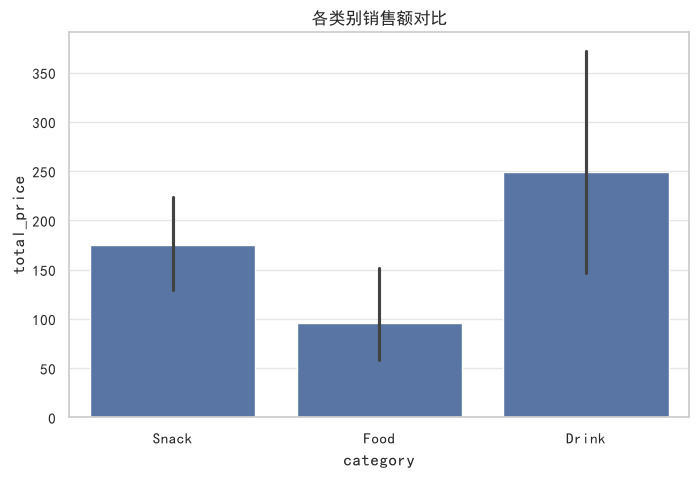

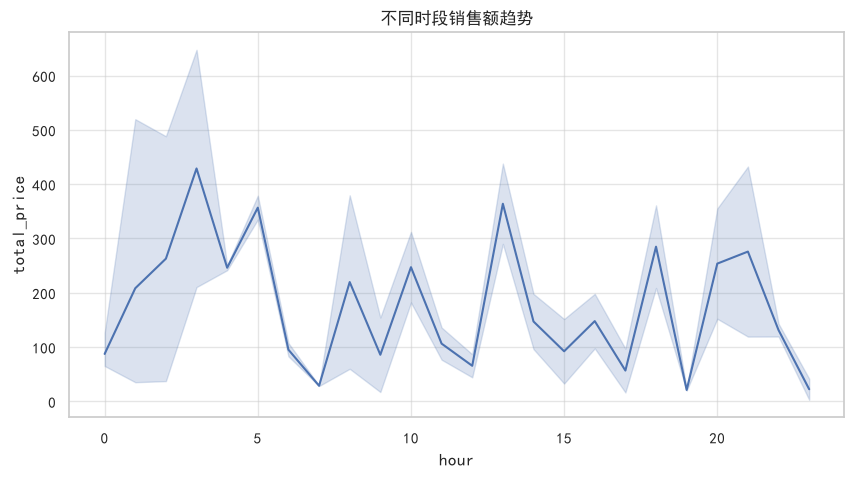

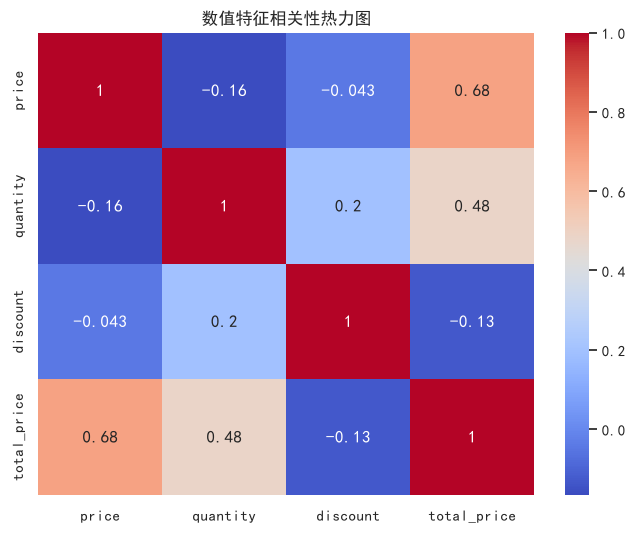

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='category', y='total_price')
plt.title("各类别销售额对比")
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='hour', y='total_price')
plt.title("不同时段销售额趋势")
plt.show()

num_cols=df[['price','quantity','discount','total_price']]
plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.title("数值特征相关性热力图")
plt.show()
